# Data Analysis for the Circle Swap Experiment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl

In [2]:
def parse_experiment_data(barrier_name: str, num_robots: int) -> tuple[float, float, list[float]]:
    """
    Parse the experiment data for a given experiment

    Args:
        barrier_name (str): The name of the barrier used in the experiment.
        num_robots (int): The number of robots used in the experiment.
    Returns:
        tuple[float, float, list[float]]: A tuple containing the minimum h value, total completion time, and a list of individual completion times.
    """
    log_file = f"../circle_swap/{barrier_name}/{num_robots}.txt"
    min_h = np.inf
    total_completion_time = np.nan
    individual_completion_times = np.zeros(num_robots)
    with open(log_file, "r") as f:
        for line in f.readlines():
            if "Experiment completed successfully" in line:
                parts = line.split(" ")
                total_completion_time = float(parts[-2])
            if "Minimum h value" in line:
                parts = line.split(" ")
                min_h = float(parts[-1])
    completion_file = f"../circle_swap/{barrier_name}/completion_times/{num_robots}.npy"
    individual_completion_times = np.load(completion_file)
    return min_h, total_completion_time, individual_completion_times


In [8]:
BARRIER_NAMES = ["progress", "decentralized", "centralized"]
NUM_ROBOTS = [i for i in range(1, 21)]
COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd", "#d62728"]

barrier_data = {
    barrier_name: {
        i: parse_experiment_data(barrier_name, i)
        for i in NUM_ROBOTS
    }
    for barrier_name in BARRIER_NAMES
}

In [10]:
def parse_dataframe_from_completion_times(barrier_data: dict[str, dict[int, tuple[float, float, list[float]]]]) -> pl.DataFrame:
    """
    Parse the completion times from the barrier data into a Polars DataFrame.

    Args:
        barrier_data (dict[str, dict[int, tuple[float, float, list[float]]]]): The barrier data containing completion times.
    Returns:
        pl.DataFrame: A Polars DataFrame containing the completion times for each barrier and number of robots.
    """
    N = [2, 4, 8, 11, 16, 20]
    return pl.DataFrame({
        "N": N,
        "Centralized Completion Time": [barrier_data["centralized"][i][1] for i in N],
        "Decentralized Completion Time": [barrier_data["decentralized"][i][1] for i in N],
        "Progress Completion Time": [barrier_data["progress"][i][1] for i in N],
        # "Increasing Completion Time": [barrier_data["increasing"][i][1] for i in N],
        # "Double Completion Time": [barrier_data["double"][i][1] for i in N],
        "Centralized Completion Percentage": [1.0 if barrier_data["centralized"][i][1] is not np.nan else 0.0 for i in N],
        "Decentralized Completion Percentage": [1.0 if barrier_data["decentralized"][i][1] is not np.nan else 0.0 for i in N],
        "Progress Completion Percentage": [1.0 if barrier_data["progress"][i][1] is not np.nan else 0.0 for i in N],
        # "Increasing Completion Percentage": [1.0 if barrier_data["increasing"][i][1] is not np.nan else 0.0 for i in N],
        # "Double Completion Percentage": [1.0 if barrier_data["double"][i][1] is not np.nan else 0.0 for i in N],
    })

df = parse_dataframe_from_completion_times(barrier_data)
df.show(limit=10)

N,Centralized Completion Time,Decentralized Completion Time,Progress Completion Time,Centralized Completion Percentage,Decentralized Completion Percentage,Progress Completion Percentage
i64,f64,f64,f64,f64,f64,f64
2,37.22,36.4,48.61,1.0,1.0,1.0
4,47.42,NaN,23.66,1.0,0.0,1.0
8,67.95,NaN,30.0,1.0,0.0,1.0
11,47.49,NaN,41.09,1.0,0.0,1.0
16,46.93,NaN,49.07,1.0,0.0,1.0
20,41.38,NaN,68.44,1.0,0.0,1.0


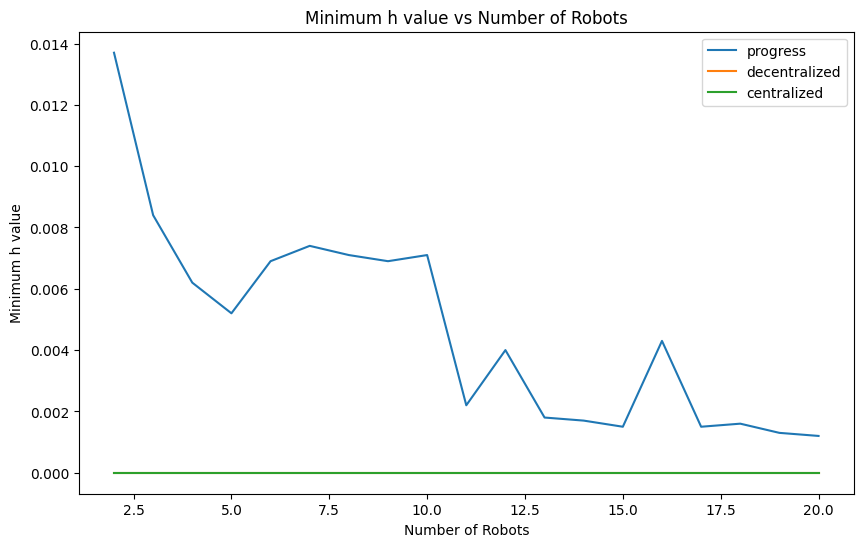

In [11]:
plt.figure(figsize=(10, 6))
for i, barrier_name in enumerate(BARRIER_NAMES):
    min_h_values = [barrier_data[barrier_name][num_robots][0] for num_robots in NUM_ROBOTS]
    plt.plot(
        NUM_ROBOTS,
        min_h_values,
        label=barrier_name,
        color=COLORS[i]
    )
plt.title("Minimum h value vs Number of Robots")
plt.xlabel("Number of Robots")
plt.ylabel("Minimum h value")
plt.legend()
plt.show()


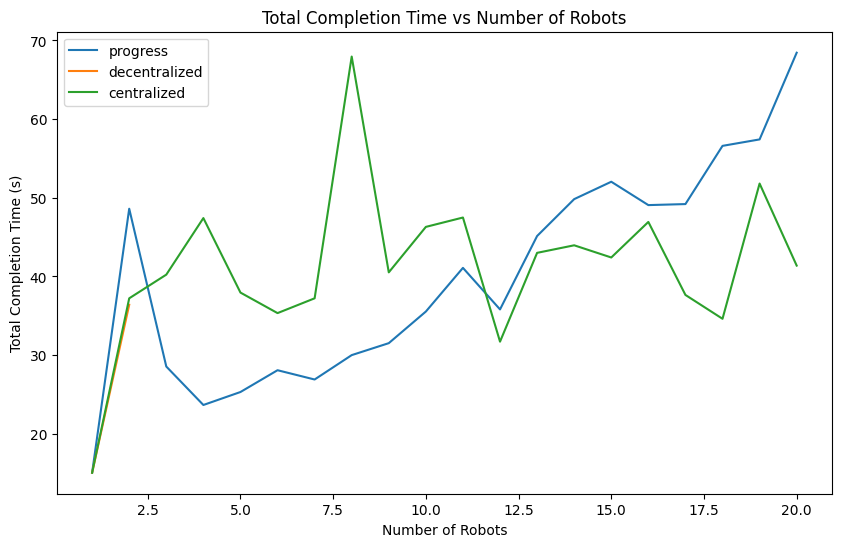

In [12]:
plt.figure(figsize=(10, 6))
for i, barrier_name in enumerate(BARRIER_NAMES):
    total_completion_times = [barrier_data[barrier_name][num_robots][1] for num_robots in NUM_ROBOTS]
    plt.plot(
        NUM_ROBOTS,
        total_completion_times,
        label=barrier_name,
        color=COLORS[i]
    )
plt.title("Total Completion Time vs Number of Robots")
plt.xlabel("Number of Robots")
plt.ylabel("Total Completion Time (s)")
plt.legend()
plt.show()

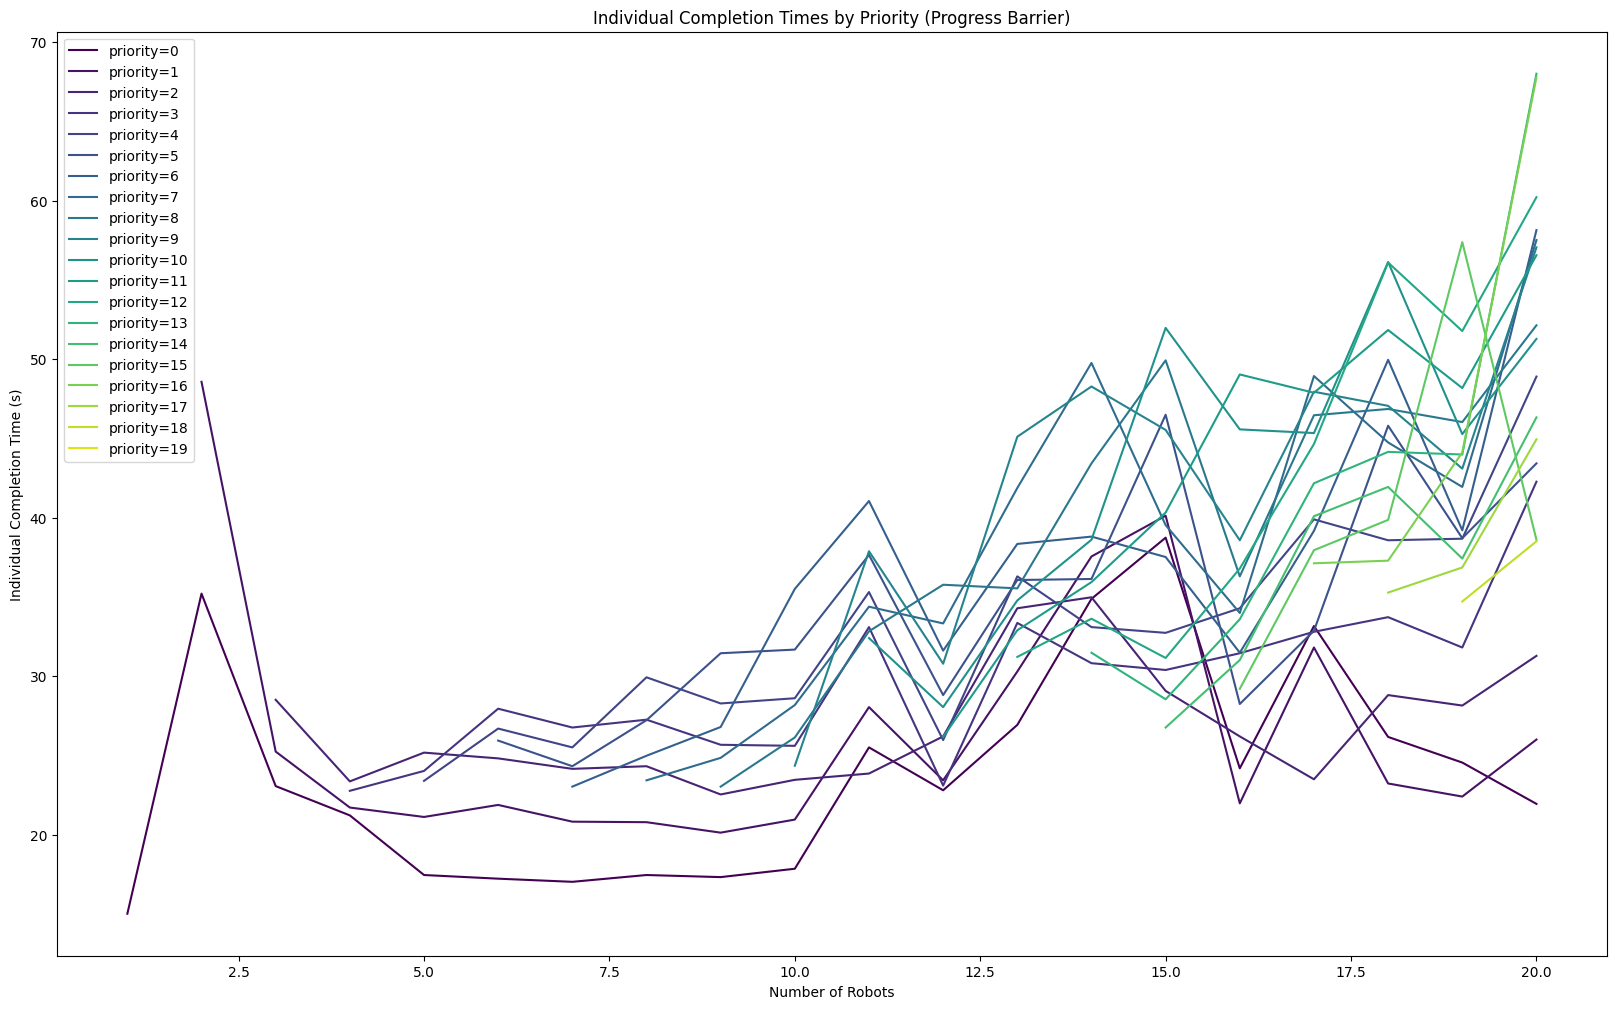

In [13]:
plt.figure(figsize=(20, 12))
for priority in range(len(NUM_ROBOTS)):
    data = np.full(len(NUM_ROBOTS), np.nan)
    for i in range(priority, len(NUM_ROBOTS)):
        data[i] = barrier_data["progress"][i+1][2][priority]
        if data[i] == 0.0:
            data[i] = np.nan
    plt.plot(
        NUM_ROBOTS,
        data,
        label=f"priority={priority}",
        color=plt.cm.viridis(priority / len(NUM_ROBOTS))
    )
plt.title("Individual Completion Times by Priority (Progress Barrier)")
plt.xlabel("Number of Robots")
plt.ylabel("Individual Completion Time (s)")
plt.legend()
plt.show()